# INITIALIZATION OF THE LOAN PREDICTION MODEL
This data set would provide you enough taste of working on data sets from insurance companies, what challenges are faced, what strategies are used, which variables influence the outcome etc. This is a classification problem. 

This is used to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. 

In [119]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import os


breast_cancer_df = pd.read_csv(r'..\Training Datasets\Breast_cancer.csv')
breast_cancer_df.info()
print(os.getcwd())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

# DATA CLEANING

In [120]:
# 1. Drop the ID column and the accidental empty 33rd column
breast_cancer_df = breast_cancer_df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [121]:
# CHECKING IF THERE ARE ANY DUPLICATES AND REMOVING THEM

print("No. of duplicated values are: ",breast_cancer_df.duplicated().sum(),'\n')
# CHECKING THE NO. OF NULL VALUES IN THE FEATURES
print("Columns with the number of null values:\n",breast_cancer_df.isnull().sum())


No. of duplicated values are:  0 

Columns with the number of null values:
 diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [122]:
breast_cancer_df.columns.tolist()

['diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [123]:
error_columns = [
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se'
]

worst_case_columns = [
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# 2. Combine all lists into one single master list of columns to drop
all_redundant_columns = error_columns + worst_case_columns 

# 3. Drop them all in one clean step
# errors='ignore' ensures the code doesn't crash if a column name is slightly misspelled
breast_cancer_df = breast_cancer_df.drop(columns=all_redundant_columns, errors='ignore')


In [124]:
breast_cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    str    
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
dtypes: float64(10), str(1)
memory usage: 49.6 KB


In [125]:
# CHECKING THE UNIQUE CATEGORICAL VALUES IN THE TARGET
breast_cancer_df['diagnosis'].unique()


<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

M - Malignant (Cancerous)
B - Benign (Non-cancerous)

In [126]:
# Encode target Feature
# M - 1(True)
# B - 0(False)
#breast_cancer_df['diagnosis'] = breast_cancer_df['diagnosis'].map({'M': 1, 'B': 0})
breast_cancer_df.head(9)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389


SPLITTING OF THE DATASET COMES BEFORE SCALING OF THE FEATURES

The Correct Workflow:

Split your data into training and testing sets .

Fit and Transform the scaler on the training set only (scaler.fit_transform(X_train)).

Transform the test set using that same scaler (scaler.transform(X_test))—do not re-fit.

1. SPLITTING THE DATASET

In [127]:
# SPLITTING THE  breast_cancer_df DATASET INTO THE TRAINING AND TESTING SECTIONS

# SPLITTING IT FIRST INTO TRAINING SET AND TEST SET FIRST (80%- training and validation, 20%- testing)
from sklearn.model_selection import train_test_split


train_df,  test_df = train_test_split(breast_cancer_df, test_size=0.2, random_state=42)

print('Training dataframe shape: ', train_df.shape, '\n')
print('Testing dataframe shape: ', test_df.shape, '\n')

Training dataframe shape:  (455, 11) 

Testing dataframe shape:  (114, 11) 



IDENTIFYING THE INPUT AND TARGET FEATURES

In [128]:
# SEPARATION OF THE INPUT FEATURE  FROM THE TARGET FEATURE 
inputs = breast_cancer_df.drop(columns=['diagnosis']).columns.tolist()
target = 'diagnosis'

In [129]:
# CREATING INPUTS AND TARGETS COPIES FOR THE TRAINING AND TEST SETS  MODEL TRAINING

train_inputs = train_df[inputs].copy()
train_target = train_df[target].copy()

test_inputs = test_df[inputs].copy()
test_target = test_df[target ].copy()



SCALING OF THE TRAINING AND TEST INPUT VALUES FOR PROPER OPTIMIZATION

Scaling transforms your numeric features so they're on comparable ranges before feeding them into the model.

N/B  

fit the scaler only on train_inputs, then use .transform() (not .fit_transform()) on testing_inputs. If you fit on the test set too, information from the test set leaks into your training process (data leakage), which gives you an overly optimistic — and invalid — sense of how well the model generalizes.

In [130]:
from sklearn.preprocessing import StandardScaler

# Initializing the scaler
scaler = StandardScaler()

# Fit on training data only, then transform both sets
train_inputs[inputs]= scaler.fit_transform(train_inputs[inputs])
test_inputs[inputs]= scaler.transform(test_inputs[inputs])  # transform only — no fit, avoids data leakage

# Quick view bypass
#train_inputs_scaled_df = pd.DataFrame(train_inputs)
train_inputs.head(6)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
68,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173
181,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396
63,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379
248,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041
60,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213
15,0.119585,1.960655,0.199535,0.012473,1.305462,1.066165,0.944840,0.667050,1.791935,1.112673


TRAINING AND VISUALIZING DECISION TREES

A decision tree represents a hierarchical series of binary decisions

We let the computer figure out the optimal structure & hierachy of decisions instead of manually

TRAINING

Given the target feature is classified into either Malignant(M/1) or Benign(B/0), then we use  DecisionTreeClassifier

Otherwise if continuous use DecisionTreeRegressor

In [131]:
from sklearn.tree import DecisionTreeClassifier 

# Initializing the Model

decision_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,class_weight='balanced',random_state=42)

In [132]:
# FIT THE MODEL

decision_model.fit(train_inputs, train_target)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

EVALUATION

Using the Accuracy score

Tune Decision Tree model to fix overfitting and improve test accuracy

- Set max_depth=3 and min_samples_leaf=5 to prune the tree

- Fixed overfitting issue where training accuracy was a perfect 1.0

- Increased overall test accuracy from 93% to 96%

- Reduced test set false alarms (False Malignants) from 5 to 1


In [133]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_preds = decision_model.predict(train_inputs)
train_preds[0:6]

array(['B', 'M', 'B', 'B', 'B', 'M'], dtype=object)

In [134]:
train_target[0:6]

68     B
181    M
63     B
248    B
60     B
15     M
Name: diagnosis, dtype: str

In [135]:
# Checking the counts of the predictions
pd.Series(train_preds).value_counts()

B    280
M    175
Name: count, dtype: int64

In [136]:
# CHECKING THE ACCURACY BETWEEN THE TRAIN TARGET AND PREDICTIONS
print("THE ACCURACY SCORE IN TRAINING IS: ", accuracy_score(train_preds, train_target))

THE ACCURACY SCORE IN TRAINING IS:  0.9472527472527472


In [137]:
# CHECKING THE ACCURACY BETWEEN THE TEST TARGET AND PREDICTIONS

# 1. Generate predictions for the test set
test_preds = decision_model.predict(test_inputs)

# 2. Calculate the test accuracy score
test_accuracy = accuracy_score(test_preds, test_target)
print("THE TEST ACCURACY IS: ", test_accuracy)

THE TEST ACCURACY IS:  0.9473684210526315


In [138]:
# 1. Generate the Confusion Matrix
cm = confusion_matrix(test_target, test_preds)
print("--- Confusion Matrix ---")
print(cm)
print("""
[ [True Benign,   False Malignant],
  [False Benign,  True Malignant] ]
""")

# 2. Detailed Performance Report (Precision, Recall, F1-Score)
print("--- Detailed Classification Report ---")
print(classification_report(test_target, test_preds))

--- Confusion Matrix ---
[[67  4]
 [ 2 41]]

[ [True Benign,   False Malignant],
  [False Benign,  True Malignant] ]

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           B       0.97      0.94      0.96        71
           M       0.91      0.95      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



VISUALIZATION OF THE DECISION TREE

[Text(0.5416666666666666, 0.875, 'concave points_mean <= 0.079\ngini = 0.5\nsamples = 455\nvalue = [227.5, 227.5]'),
 Text(0.3333333333333333, 0.625, 'area_mean <= 0.118\ngini = 0.168\nsamples = 282\nvalue = [211.591, 21.538]'),
 Text(0.4375, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'texture_mean <= 0.561\ngini = 0.084\nsamples = 266\nvalue = [206.023, 9.423]'),
 Text(0.08333333333333333, 0.125, 'gini = 0.03\nsamples = 224\nvalue = [176.591, 2.692]'),
 Text(0.25, 0.125, 'gini = 0.303\nsamples = 42\nvalue = [29.432, 6.731]'),
 Text(0.5, 0.375, 'texture_mean <= -0.703\ngini = 0.431\nsamples = 16\nvalue = [5.568, 12.115]'),
 Text(0.4166666666666667, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [3.977, 0.0]'),
 Text(0.5833333333333334, 0.125, 'gini = 0.205\nsamples = 11\nvalue = [1.591, 12.115]'),
 Text(0.75, 0.625, 'texture_mean <= -1.189\ngini = 0.133\nsamples = 173\nvalue = [15.909, 205.962]'),
 Text(0.6458333333333333, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.

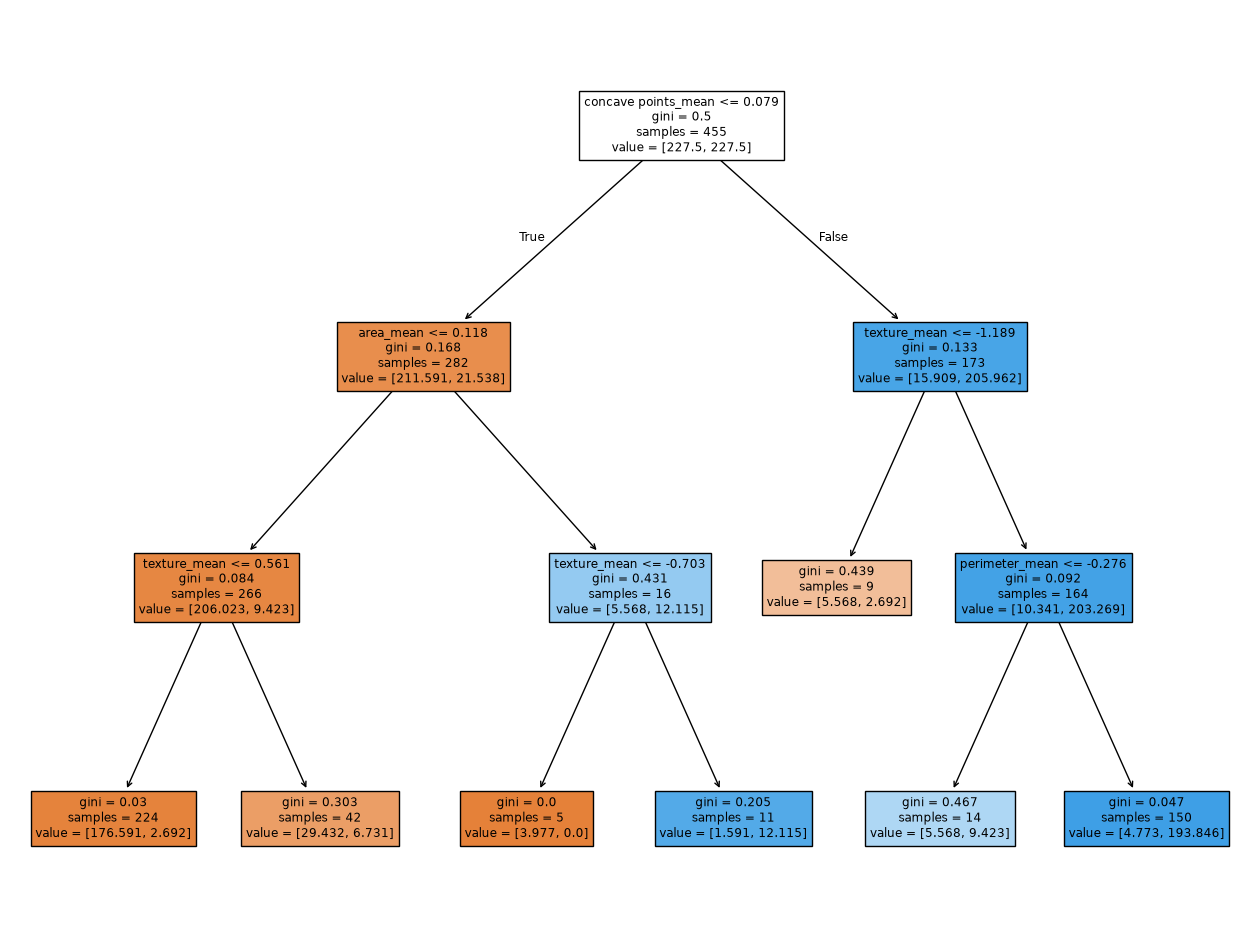

In [140]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(16,12))
plot_tree(decision_model, feature_names=train_inputs.columns, max_depth=5, filled=True)